# Building models:

In this file, we will build, train and compare the classification that various supervised models achieve. The models we will use through this notebook are the following:
1. *K-Nearest Neighbours*
2. *Decision Trees*
3. Ensemble bagging models: *Random Forest*
4. Ensemble boosting models: *Ada Boost*

Let's delve into it!

## 0- General overview of the dataset:

We made a quick Exploratory Data Analysis in the previous notebook. We shall only outline the main findings we made about the dataset.

The dataset contains information about 30 m x 30 m squares of land belonging to 4 closely located forests in the Roosvelt National Forest in Colorado, US. The 0.25 GB sized dataset contains 12 features and more than 500,000 entries. There are 10 numerical continuous features obtained from satellite data, like elevation, slope, shade index, distance to water sources and wildfire beginning points and more. The 2 remaining features are categorical: the first marks the belonging of the square terrain to one of the previously mentioned forests (Rawah, Neota, Comanche Peak and Coche la Poudre), while the last one yields the type of soil that can be found in that piece of land, from 40 different soil types. These last 2 features have been **one-hot encoded** in the dataset, so we have 54 columns for our features.

Lastly, the variable we want to predict through different machine learning models is the **Forest Cover Type**. It is also a categorical variable, which marks which of 7 different tree species covers that square piece of the forest.

First of all, let's import all the necessary modules we will be using in throughout this notebook:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Let's also load the dataset:

In [3]:
df = pd.read_csv("../data/raw/covtype.csv")
columns = df.columns

En el paper indican que el dataset está ordenado, y que los primeros 11340 registros pertenecen al dataset utilizado para entrenar el modelo. Los siguientes

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581012 non-null 

In [4]:
train_size = 11340 # Train size in the article
validation_size = 3780 # Validation size in the article
train_size += validation_size

X = df.loc[:, :"Soil_Type40"]
y = df.iloc[:, -1]

del df

In [5]:
X_train = X.iloc[:train_size, :]
X_test = X.iloc[train_size:, :]
y_train = y[:train_size]
y_test = y[train_size:]
print(f"Traing data shapes: X: {X_train.shape}, y: {y_train.shape}")
print(f"Test data shapes: X: {X_test.shape}, y: {y_test.shape}")

Traing data shapes: X: (15120, 54), y: (15120,)
Test data shapes: X: (565892, 54), y: (565892,)


In [6]:
y_train.value_counts()

Cover_Type
5    2160
2    2160
1    2160
7    2160
3    2160
6    2160
4    2160
Name: count, dtype: int64

## 1 - K- Nearest Neighbours:

KNN may not be the best model for our data for the following reasons:
- KNN works best with smaller datasets. Our dataset has a big number of entries.
- After doing one-hot encoding for the categorical variables, the dataset has a large number of dimensions. Even though variables have been scaled, KNN has a big computational cost when such a large number of variables are involved.

Any way, let's see how the model performs.

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [13]:
st_scaler = StandardScaler()

st_scaler.fit(X_train)
X_train_scaled = st_scaler.transform(X_train)
X_test_scaled = st_scaler.transform(X_test)
print(f"New shape of training data: {X_train_scaled.shape}")
print(f"New shape of test data: {X_test_scaled.shape}")

New shape of training data: (15120, 54)
New shape of test data: (565892, 54)


Our dataset is heavy, so we shall liberate some memory:

In [16]:
del X_train, X_test, X, y

We will make a first attempt of finding the best value for `k` through large steps of it:

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

knn_results = {}

for k in range(5, 40, 5):
    print(k) # Just to know what the progression is
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_knn = knn.predict(X_test_scaled)
    knn_results[k] = accuracy_score(y_test, y_knn)

5
10
15
20
25
30
35


In [18]:
knn_results

{5: 0.6423222098916401,
 10: 0.6098478154842266,
 15: 0.5892272730485676,
 20: 0.5754932036501664,
 25: 0.5650883914245121,
 30: 0.5555424003166682,
 35: 0.5475461748884947}

There seems to be an accuracy maximum around $k = 5$.

In [26]:
knn_results = {
    "train": [],
    "test": []
}

for k in range(2, 10):
    print(k) # Just to know what the progression is
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_knn = knn.predict(X_test_scaled)
    knn_results["train"].append(knn.score(X_train_scaled, y_train))
    knn_results["test"].append(accuracy_score(y_test, y_knn))

2
3
4
5
6
7
8
9


In [32]:
knn_results

{'train': [0.9288359788359788,
  0.8992724867724867,
  0.8833994708994709,
  0.8658730158730159,
  0.8528439153439153,
  0.8433862433862434,
  0.8357142857142857,
  0.8249338624338625],
 'test': [0.68446806104345,
  0.6588695369434451,
  0.6537819937373209,
  0.6423222098916401,
  0.6357820926961328,
  0.6254762392824073,
  0.6232355290408771,
  0.6131929767517477]}

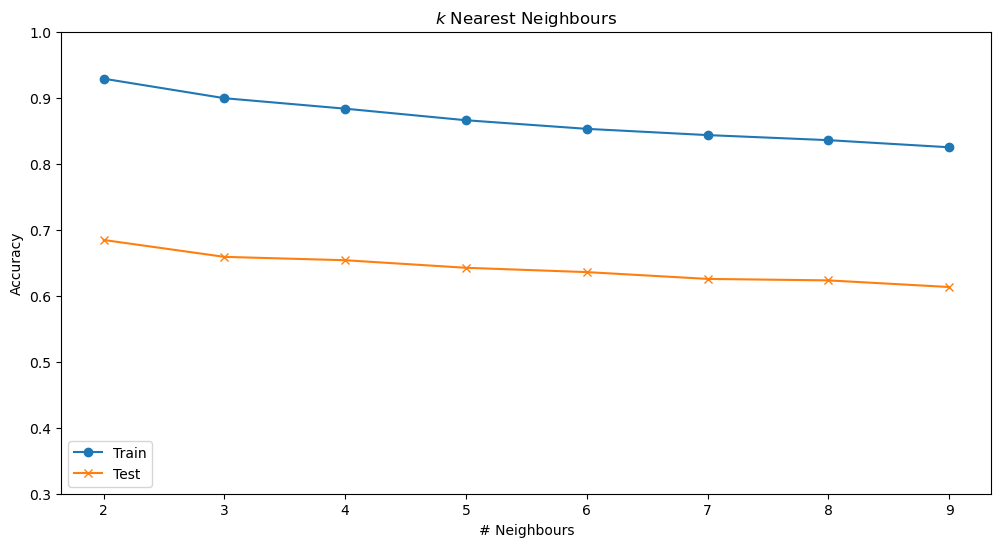

In [41]:
plt.figure(figsize=(12, 6))
plt.plot([*range(2, 10)], knn_results["train"], marker='o',label = "Train")
plt.plot([*range(2, 10)], knn_results["test"], marker='x',label = "Test")
plt.xlabel("# Neighbours")
plt.ylabel("Accuracy")
plt.ylim([0.3, 1])
plt.legend(loc = "lower left")
plt.title(r"$k$ Nearest Neighbours");

**Conclusion:**
- The accuracy monotonically decreases with k.
- There is no optimal value of $k$ that maximizes the accuracy.
- Although the simplicity of the model, with almost no preprocessing of the variables, it has shown to be a relatively good model: the accuracy values are better than for more complex model describe in the scientific paper to which this dataset belongs.

## 2- Decision Trees:

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_class = DecisionTreeClassifier()

In [45]:
from sklearn.tree import DecisionTreeClassifier

tree_class = DecisionTreeClassifier(
    max_depth = 10,
    random_state = 42,
)

tree_class.fit(X_train_scaled, y_train)
tree_predict = tree_class.predict(X_test_scaled)
print(f"max_depth=10 tree Accuracy: {accuracy_score(y_test, tree_predict)}")

max_depth=10 tree Accuracy: 0.6186887250570781


Is not that much. Let's perform some Grid Search in order to find a better configuration for the model:

In [8]:
from sklearn.model_selection import GridSearchCV

tree_class = DecisionTreeClassifier(random_state=42, 
                                    min_samples_leaf = 5 # Avoid overfitting
                                   )

parameters = {
    "max_depth": [i for i in range(3, 31, 3)],
    "criterion": ["gini", "entropy"] # Compare two different ways of measuring the quality of a split
}

gs_cv = GridSearchCV(
    estimator = tree_class,
    param_grid = parameters,
    scoring = "accuracy",
    verbose =  3,
    return_train_score = True
)

In [51]:
gs_cv.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END criterion=gini, max_depth=3;, score=(train=0.620, test=0.490) total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=3;, score=(train=0.617, test=0.560) total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=3;, score=(train=0.588, test=0.595) total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=3;, score=(train=0.595, test=0.570) total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=3;, score=(train=0.592, test=0.587) total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=6;, score=(train=0.713, test=0.575) total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=6;, score=(train=0.716, test=0.620) total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=6;, score=(train=0.707, test=0.671) total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=6;, score=(train=0.710, test=0.627) total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=6;, score=(train=0.708, test=0.701) total time=   0.0

GridSearchCV(estimator=DecisionTreeClassifier(min_samples_leaf=5,
                                              random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 6, 9, 12, 15, 18, 21, 24, 27, 30]},
             return_train_score=True, scoring='accuracy', verbose=3)

In [52]:
gs_cv.best_params_

{'criterion': 'gini', 'max_depth': 21}

In [53]:
gs_cv.best_score_

np.float64(0.6981481481481481)

In [56]:
gs_cv.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_criterion', 'param_max_depth', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score', 'split0_train_score', 'split1_train_score', 'split2_train_score', 'split3_train_score', 'split4_train_score', 'mean_train_score', 'std_train_score'])

In [60]:
gs_cv.cv_results_["mean_test_score"] # What parameter combinations belongs to each score?

array([0.5603836 , 0.63869048, 0.66759259, 0.69609788, 0.69708995,
       0.69609788, 0.69814815, 0.69715608, 0.69702381, 0.69656085,
       0.55787037, 0.6343254 , 0.67751323, 0.69451058, 0.6968254 ,
       0.69669312, 0.69398148, 0.69332011, 0.69298942, 0.69298942])

In [59]:
gs_cv.cv_results_["params"]

[{'criterion': 'gini', 'max_depth': 3},
 {'criterion': 'gini', 'max_depth': 6},
 {'criterion': 'gini', 'max_depth': 9},
 {'criterion': 'gini', 'max_depth': 12},
 {'criterion': 'gini', 'max_depth': 15},
 {'criterion': 'gini', 'max_depth': 18},
 {'criterion': 'gini', 'max_depth': 21},
 {'criterion': 'gini', 'max_depth': 24},
 {'criterion': 'gini', 'max_depth': 27},
 {'criterion': 'gini', 'max_depth': 30},
 {'criterion': 'entropy', 'max_depth': 3},
 {'criterion': 'entropy', 'max_depth': 6},
 {'criterion': 'entropy', 'max_depth': 9},
 {'criterion': 'entropy', 'max_depth': 12},
 {'criterion': 'entropy', 'max_depth': 15},
 {'criterion': 'entropy', 'max_depth': 18},
 {'criterion': 'entropy', 'max_depth': 21},
 {'criterion': 'entropy', 'max_depth': 24},
 {'criterion': 'entropy', 'max_depth': 27},
 {'criterion': 'entropy', 'max_depth': 30}]

Now, we know what the best combinations of parameters might be. We should now perform a new grid search, this time for values around max_depth = 21. 

In [19]:
tree_class = DecisionTreeClassifier()
parameters = {
    "max_depth": [i for i in range(19, 24)]
}
gs_cv = GridSearchCV(
    estimator = tree_class,
    param_grid = parameters,
    scoring = "accuracy",
    verbose =  3,
)

gs_cv.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV 1/5] END ......................max_depth=19;, score=0.699 total time=   0.1s
[CV 2/5] END ......................max_depth=19;, score=0.702 total time=   0.1s
[CV 3/5] END ......................max_depth=19;, score=0.702 total time=   0.1s
[CV 4/5] END ......................max_depth=19;, score=0.686 total time=   0.1s
[CV 5/5] END ......................max_depth=19;, score=0.780 total time=   0.1s
[CV 1/5] END ......................max_depth=20;, score=0.690 total time=   0.1s
[CV 2/5] END ......................max_depth=20;, score=0.695 total time=   0.1s
[CV 3/5] END ......................max_depth=20;, score=0.690 total time=   0.1s
[CV 4/5] END ......................max_depth=20;, score=0.677 total time=   0.1s
[CV 5/5] END ......................max_depth=20;, score=0.773 total time=   0.1s
[CV 1/5] END ......................max_depth=21;, score=0.695 total time=   0.1s
[CV 2/5] END ......................max_depth=21;,

GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [19, 20, 21, 22, 23]}, scoring='accuracy',
             verbose=3)

In [20]:
gs_cv.best_params_

{'max_depth': 19}

In [21]:
gs_cv.best_score_

np.float64(0.7138888888888889)

In [22]:
y_tree = gs_cv.predict(X_test_scaled)

Text(50.722222222222214, 0.5, 'Actual')

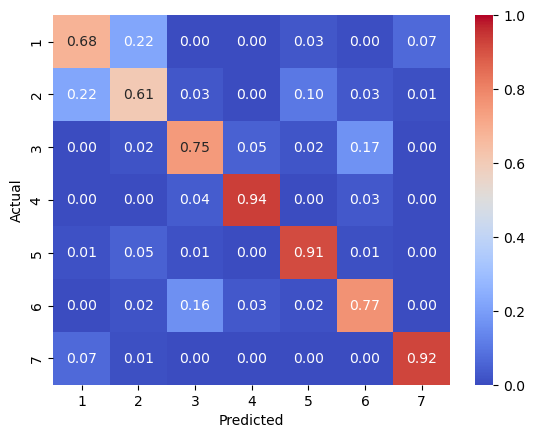

In [41]:
sns.heatmap(confusion_matrix(y_test, y_tree, normalize = "true"), cmap = "coolwarm", vmax = 1, annot = True,
            xticklabels = [i for i in range(1,8)], yticklabels = [i for i in range(1,8)], fmt = '.2f')
#plt.xlabel([i for i in range(1,8)])
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [25]:
print(f"Accuracy for Decision Tree Classifier with {gs_cv.best_params_}: {accuracy_score(y_test, y_tree):4.3f}")

Accuracy for Decision Tree Classifier with {'max_depth': 19}: 0.662


## 3- Random Forest Classifier:

### 3-1 Feature selection:

In the article from which this dataset was obtained, the authors compared the results obtained from training ML models with different subsets of features.

They compared the results they got when neglecting all the `Soil_Type` and `Wilderness_Area` columns. They also compared the results they got when using all the numerical variables except for the `Horizontal_Distance_To_Fire_Points`.

In this subsection, I want to use robust Random Forest models to see how the inclusion or exclusion of different features can improve the performance of the model.

In [42]:
from sklearn.ensemble import RandomForestClassifier

Prepare the data:

In [49]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns = columns[:-1])
X_test_scaled = pd.DataFrame(X_test_scaled, columns = columns[:-1])
X_train_short = X_train_scaled.loc[:, "Elevation":"Horizontal_Distance_To_Fire_Points"]
X_test_short = X_test_scaled.loc[:, "Elevation":"Horizontal_Distance_To_Fire_Points"]

In [55]:
X_test_scaled.shape

(565892, 54)

In [58]:
rf_class_short = RandomForestClassifier(
    n_estimators = 100,
    max_depth = 15
)

rf_class_long = RandomForestClassifier(
    n_estimators = 100,
    max_depth = 15
)

rf_class_short.fit(X_train_short, y_train)
rf_class_long.fit(X_train_scaled, y_train)

y_rf_short = rf_class_short.predict(X_test_short)
y_rf = rf_class_long.predict(X_test_scaled)

In [60]:
print(f"Short features selection accuracy: {accuracy_score(y_test, y_rf_short):4.3f}")
print(f"Whole features selection accuracy: {accuracy_score(y_test, y_rf):4.3f}")

Short features selection accuracy: 0.682
Whole features selection accuracy: 0.707


Text(792.3131313131312, 0.5, 'Actual')

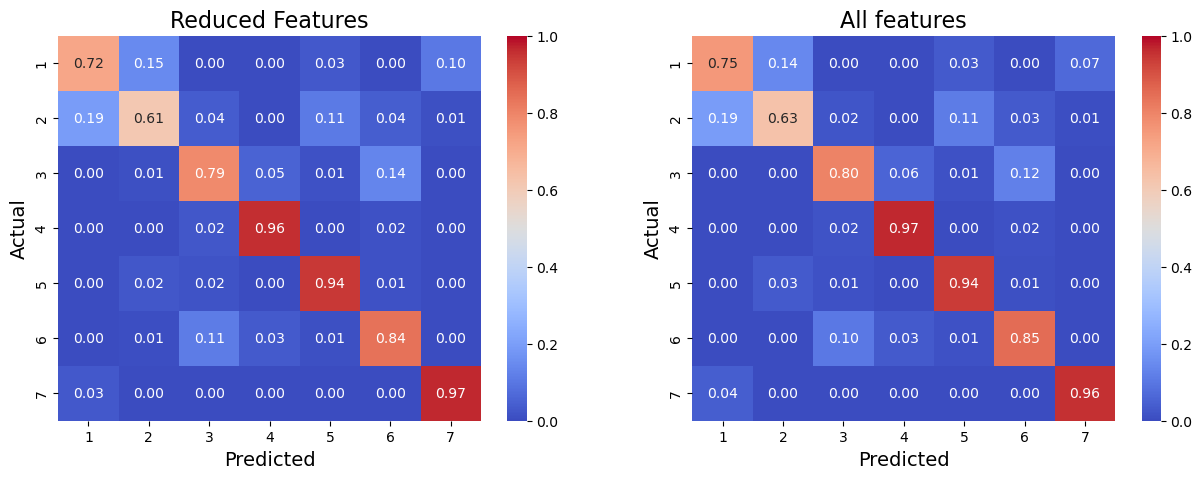

In [70]:
plt.figure(figsize = (15,5))
plt.subplot(1,2,1)
sns.heatmap(confusion_matrix(y_test, y_rf_short, normalize = "true"), cmap = "coolwarm", vmax=1, annot=True,
           xticklabels = [i for i in range(1,8)], yticklabels = [i for i in range(1,8)], fmt = '.2f')
plt.title("Reduced Features", fontsize = 16)
plt.xlabel("Predicted", fontsize = 14)
plt.ylabel("Actual", fontsize = 14)
plt.subplot(1,2,2)
sns.heatmap(confusion_matrix(y_test, y_rf, normalize = "true"), cmap = "coolwarm", vmax=1, annot=True,
           xticklabels = [i for i in range(1,8)], yticklabels = [i for i in range(1,8)], fmt = '.2f')
plt.title("All features", fontsize = 16)
plt.xlabel("Predicted", fontsize = 14)
plt.ylabel("Actual", fontsize = 14)

In [ ]:
#sns.heatmap(confusion_matrix(y_test, y_rf, normalize = "true"), cmap = "coolwarm", vmax=1, annot=True,
#           xticklabels = [i for i in range(1,8)], yticklabels = [i for i in range(1,8)], fmt = '.2f')
#plt.title("All features", fontsize = 16)
#plt.xlabel("Predicted", fontsize = 14)
#plt.ylabel("Actual", fontsize = 14)

First things first:
- The choosen values of `n_estimators` and `max_depth` show good results.
- Including the categorical variables improve the accuracy a little bit: 2%. The most important variables are actually the numerical ones!

However, we will want to keep that little improvement in the metric that keeping all the columns gives us.

### 3-2 Random Forest Grid Search:

Let's now try to find the best parameters for a Random Forest Classifier. The parameters we want to vary are `n_estimators` and `max_depth`.

In [71]:
rf_class = RandomForestClassifier(random_state = 42, min_samples_split=10)
# We fix min_samples_split in order to avoid overfitting for the biggest depth values

parametros = {
    "n_estimators": [50, 100, 150, 200, 250, 300],
    "max_depth": [10, 15, 20, 25, 30],
}

gs_cv = GridSearchCV(
    estimator = rf_class,
    param_grid = parametros,
    scoring = "accuracy",
    cv = 5,
    verbose = 3,
)

gs_cv.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5] END .....max_depth=10, n_estimators=50;, score=0.656 total time=   0.7s
[CV 2/5] END .....max_depth=10, n_estimators=50;, score=0.679 total time=   0.6s
[CV 3/5] END .....max_depth=10, n_estimators=50;, score=0.699 total time=   0.6s
[CV 4/5] END .....max_depth=10, n_estimators=50;, score=0.751 total time=   0.6s
[CV 5/5] END .....max_depth=10, n_estimators=50;, score=0.788 total time=   0.6s
[CV 1/5] END ....max_depth=10, n_estimators=100;, score=0.667 total time=   1.3s
[CV 2/5] END ....max_depth=10, n_estimators=100;, score=0.689 total time=   1.3s
[CV 3/5] END ....max_depth=10, n_estimators=100;, score=0.701 total time=   1.3s
[CV 4/5] END ....max_depth=10, n_estimators=100;, score=0.754 total time=   1.3s
[CV 5/5] END ....max_depth=10, n_estimators=100;, score=0.790 total time=   1.3s
[CV 1/5] END ....max_depth=10, n_estimators=150;, score=0.669 total time=   2.0s
[CV 2/5] END ....max_depth=10, n_estimators=150

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(min_samples_split=10,
                                              random_state=42),
             param_grid={'max_depth': [10, 15, 20, 25, 30],
                         'n_estimators': [50, 100, 150, 200, 250, 300]},
             scoring='accuracy', verbose=3)

Let's now check what's the accuracy of the model with the best parameter values:

In [72]:
gs_cv.best_params_

{'max_depth': 25, 'n_estimators': 150}

In [73]:
gs_cv.best_score_

np.float64(0.7707671957671958)

In [76]:
print(f"150 estimators, max_depth = 25. Accuracy: {accuracy_score(y_test, gs_cv.predict(X_test_scaled)):4.3f}")

150 estimators, max_depth = 25. Accuracy: 0.735


Hhhhm, interesting. Previously, while making some scratch models, I found that for a smaller subset of training data (remember that in this notebook we used the first 15000 registers, but that in the article they used 11000 registers as the training dataset and the remaining 4000 as a validation set to train an artificial neural network) the best parameters were `max_depth`=25 and `n_estimators`=250.

I think that more focus should be put on the process by which the authors choose the entries for the training dataset, and the dependence that the score has on the training dataset size should also be checked.

## 4- Boosting models:

Boosting models are ensemble models in which, instead of running many models in parallel, each model is run one after the other, and contrary to what bagging ensemble models like Random Forest, the model outputs are used as an input for the next model in the sequence.

One important parameter present in boosting models is the parameter known as the **learning rate**. The learning rate controls how the output of one of the sequence models is used in the next model in the sequence.

### 4.1- AdaBoost models:

AdaBoost models consist of a sequence of models of the same type (Decision Trees typically), in which the output of a model is used as an input feature for the next model in the sequence. The learning rate softens the influence of this new feature to avoid *overfitting* by it. Let's build some AdaBoost model and compare its results with those of the previous ensemble models used.

Sequential models take longer to train than bagging models, which are executed in parallel. To avoid long and cumbersome computation times, it's better to pick a smaller set of parameters while performing the grid search.

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    estimator = DecisionTreeClassifier(random_state = 42, min_samples_split = 10),
    random_state = 42,
)

params_ada = {
    "n_estimators": [120, 220],
    "learning_rate": [0.3, 0.6],
    "estimator__max_depth": [i for i in range(16, 25, 4)],
}

gs_ada = GridSearchCV(
    estimator = ada,
    param_grid = params_ada,
    scoring = "accuracy",
    cv = 5,
    verbose = 3,
)

In [85]:
gs_ada.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END estimator__max_depth=16, learning_rate=0.3, n_estimators=120;, score=0.783 total time=  23.9s
[CV 2/5] END estimator__max_depth=16, learning_rate=0.3, n_estimators=120;, score=0.771 total time=  25.2s
[CV 3/5] END estimator__max_depth=16, learning_rate=0.3, n_estimators=120;, score=0.788 total time=  23.2s
[CV 4/5] END estimator__max_depth=16, learning_rate=0.3, n_estimators=120;, score=0.804 total time=  23.9s
[CV 5/5] END estimator__max_depth=16, learning_rate=0.3, n_estimators=120;, score=0.864 total time=  23.7s
[CV 1/5] END estimator__max_depth=16, learning_rate=0.3, n_estimators=220;, score=0.780 total time=  44.7s
[CV 2/5] END estimator__max_depth=16, learning_rate=0.3, n_estimators=220;, score=0.774 total time=  42.9s
[CV 3/5] END estimator__max_depth=16, learning_rate=0.3, n_estimators=220;, score=0.790 total time=  44.5s
[CV 4/5] END estimator__max_depth=16, learning_rate=0.3, n_estimators=220;, score=0

GridSearchCV(cv=5,
             estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier(min_samples_split=10,
                                                                           random_state=42),
                                          random_state=42),
             param_grid={'estimator__max_depth': [16, 20, 24],
                         'learning_rate': [0.3, 0.6],
                         'n_estimators': [120, 220]},
             scoring='accuracy', verbose=3)

Good! After a long time, the grid search will show its results. Hopefully, they will be even better than the ones we got using Random Forest. Let's see!

In [86]:
gs_ada.best_score_

np.float64(0.8069444444444445)

In [87]:
gs_ada.best_params_

{'estimator__max_depth': 20, 'learning_rate': 0.6, 'n_estimators': 220}

In [89]:
print(f"AdaBoost accuracy (learning_rate=0.6, n_estimators=220, max_depth=20): {accuracy_score(y_test, gs_ada.predict(X_test_scaled)):4.3f}")

AdaBoost accuracy (learning_rate=0.6, n_estimators=220, max_depth=20): 0.775


#### Saving the model for later use:

Performing this grid search has taken me a long time, and having to train a new model takes some time. Instead of having to train our model again each time we want to predict something, it is better to save the in a pickle file. Saving the GridSeach instance occupies too much memory, so instead we are going to train a model with the best optimal parameters and save it:

In [19]:
estimator = DecisionTreeClassifier(
    max_depth = 20,
    min_samples_leaf = 10,
    random_state=42
)

ada_boost = AdaBoostClassifier(
    estimator = estimator,
    n_estimators = 220,
    learning_rate = 0.6,
)

In [20]:
ada_boost.fit(X_train_scaled, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=20,
                                                    min_samples_leaf=10,
                                                    random_state=42),
                   learning_rate=0.6, n_estimators=220)

In [26]:
import pickle
with open("./models/ada_boost_best_model.pkl", "wb") as file:
    pickle.dump(ada_boost, file)

The model has been trained with scaled data, so the StandarScaler instance should also be saved in order to scale the data with the user input:

In [25]:
with open("./models/standard_scaler.pkl", "wb") as file:
    pickle.dump(st_scaler, file)

## 5- Unsupervised models: combination with supervised models

Unsupervised models in machine learning work without a target variable, and they are often used as a preprocessing step. In this context, one of the most extended methods is **Primary Component Analysis**. PCA finds those directions in the data space that produce the most variance. It helps find those dimensions that produce changes in the data and neglect the dimensions that bring just noise.

PCA has a big downside, and it is that sometimes the directions of the Primary Components are hard to interpret, as they might involve several original variables of the data.

That said, let's calculate the 30 first Primary Components and see how that affects the precision of previous models!

In [100]:
from sklearn.decomposition import PCA

pca = PCA(n_components=40)

converted_data = pca.fit_transform(X_train_scaled)
X_test_converted = pca.transform(X_test_scaled)

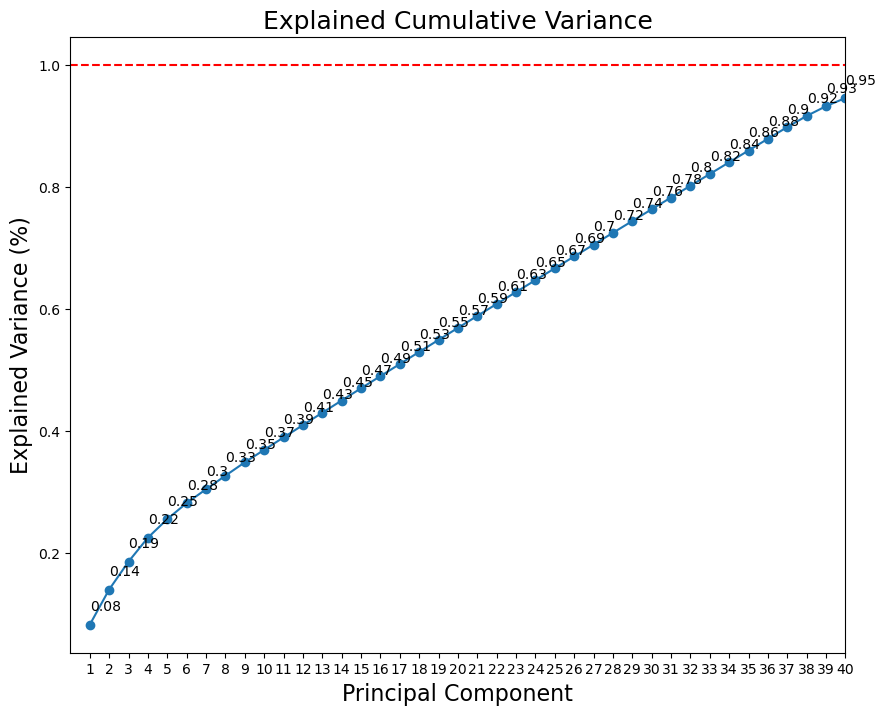

In [101]:
plt.figure(figsize=(10, 8))

plt.plot(
    np.arange(1, pca.n_components_ + 1),
    pca.explained_variance_ratio_.cumsum(),
    marker = 'o'
)

plt.xlabel("Principal Component", fontsize = 16)
plt.ylabel("Explained Variance (%)", fontsize = 16)
plt.xticks(np.arange(1, pca.n_components_ + 1));
plt.axhline(1, color = "red", linestyle = "--")
#plt.xlim(2) # No funciona
plt.xlim(0, 40)
plt.title("Explained Cumulative Variance", fontsize = 18)
for x, y in zip(np.arange(1, pca.n_components_ + 1), pca.explained_variance_ratio_.cumsum()):
    label = round(y, 2) # Redondear y hasta dos decimales
    plt.annotate( # annotate: write things in the plot
        label, # what we want to write
        (x, y), # The point that is going to be annotated (no es la posición de la anotación, es el punto que se está comentando)
        textcoords = "offset points", # textcoords: unidades en las que se va a expresar la coordenada respecto al punto anotado
        # "offset points": unidades--> puntos
        xytext = (0, 10),
        #ha = "center"
    )

In [102]:
converted_data.shape

(15120, 40)

In [103]:
X_test_converted.shape

(565892, 40)

Decision Tree models, which are the base of many ensemble models like Random Forest, are resistant to noisy dimensions. PCA should not increase the precision of the previous models by a large extent. Instead, even if we pick all the calculated PCs, we might even get worse scores. Anyway, let's try to at least get some insight on the performance improvement of ensemble models by combining them with PCA:

In [110]:
train_accuracy = []
test_accuracy = []
matrix = []

for i in range(10, 41, 10): # We will just take the PCs in batches of size 10
    rf_class = RandomForestClassifier( # We will use simmilar parameters to the RF section
        n_estimators=120,
        max_depth=19,
        min_samples_split=10,
        random_state=42,
    )
    X_train = converted_data[:, :i]
    X_test = X_test_converted[:, :i]

    rf_class.fit(X_train, y_train)
    y_predict = rf_class.predict(X_test)
    train_accuracy.append(rf_class.score(X_train, y_train))
    test_accuracy.append(accuracy_score(y_test, y_predict))
    matrix.append(confusion_matrix(y_test, y_predict))
    print(f"{i} PC calculation completed")

10 PC calculation completed
20 PC calculation completed
30 PC calculation completed
40 PC calculation completed


In [111]:
train_accuracy

[0.9632275132275132, 0.9625, 0.9667989417989418, 0.9671296296296297]

In [112]:
test_accuracy

[0.6818403511624126,
 0.6814038721169411,
 0.6892269196242392,
 0.6896757685212019]

There is a huge difference between the training dataset accuracy and the test dataset accuracy, a clear clue of overfitting.

## 6- Conclusions:

It has been really fun to delve deep into a dataset and comparing the performance of different models. This has been my first serious project in ML, and even though I think that many improvements can be made to this notebook, the results have been really good.

The article authors used two models:
- A Discriminant Analysis model, with an accuracy of 58%.
- An Artificial Neural Network, with an accuracy of 70%.

All our models have proved to perform better than the Discriminant Analysis model used by the authors. Even the simplest of our models, the Decision Tree Classifier, with 66.2% accuracy value, has been really close to a more complex and heavier ANN developed by the authors.

From all the models we have seen, the ensemble models (Random Forest and AdaBoost, with 73.5% and 77.5% accuracies respectively) have proved to be more accurate than the ANN developed by the authors. This has been an unexpected surprise, and it is interesting to see that some models that are considered *classical* with little customization show better results than a carefully designed ANN.

To summ it up:
1. Eventhough the KNN model has shown some good accuracy values, it is better suited for more compact datasets. The great number of dimensions that this dataset has discourages people from further using this model.
2. Although Decision Trees are relatively simple models, they show a good enough accuracy while being computationally light.
3. Random Forest surpasses the ANN. Further customization may rise its accuracy above 80%.
4. AdaBoost has proven to be an even better model than Random Forest, at the expense of being computationally heavy. The grid search was very limited with little exploration of the parameter space. Given enough time, AdaBoost models could strike accuracy values close to 90%.
5. Dimensionality reduction through PCA has not been able to improve previous results of models that used the whole set of features. Results are not definitive. A more carefull feature selection process during the Exploratory Data Analysis step and the use of models not based in the Decision Tree might show what the PCA is capable of with this dataset.

### 6.1- Future steps:

Some possible future steps I might develop in the future:
1. A deeper EDA, in which some statistical techniques that measure how the different numeric variables are correlated to the discrete target variable could be explored. This could allow to directly drop some columns that add mostly noise to the dataset.
2. An *Artificial Neural Network* model could be developed in the future. Creating such a model for a non expert is no easy task, so I might be back in the future, once I get a better understanding of how neural networks work.

That was all! I hope you enjoyed the Notebook and please, feel free to make any suggestions.